## Bibliotecas e GPU

In [1]:
# Bibliotecas
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from funcs import modificacoes1, banco, tvt, modificacoes2
from redes.unet import unet 
from redes.unet_fuzzy import unet_fuzzy


import tensorflow as tf
from tensorflow import keras
from keras import mixed_precision
from keras.callbacks import EarlyStopping

from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, dtype=np.float32)

I0000 00:00:1774901621.610384   20015 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774901622.267755   20015 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774901625.245774   20015 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Configuração (GPU / mixed precision / strategy)

print('TensorFlow:', tf.__version__)
print('Built with CUDA:', tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print('GPUs:', gpus)
print('CPUs:', cpus)

# Importante: fazer isso ANTES de criar modelos/estratégias, para evitar reservar toda a VRAM
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print('Não foi possível habilitar memory growth:', e)

    # Mixed precision costuma reduzir MUITO o uso de VRAM em U-Net
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision policy:', mixed_precision.global_policy())

# Estratégia: só use MirroredStrategy se tiver >1 GPU
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print('Strategy:', type(strategy).__name__)

TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
Strategy: _DefaultDistributionStrategy


## Criando o banco de dados

In [3]:
""" Renomeia os arquivos do label_studio """
# path_y_train = 'banco2/Nelore2/label_studio'
# path_x_train = 'banco2/Nelore2/img_corte'
# y_destino = 'banco2/Nelore2/label_egl'
# lista_img_train = sorted(os.listdir(path_x_train))
# lista_img_label = sorted(os.listdir(path_y_train))
# print(lista_img_label)

# for i,nome_arquivo in enumerate(lista_img_label):
#     caminho = os.path.join(path_y_train, nome_arquivo)
#     img = cv2.imread(caminho)

#     nome_limpo, ext = os.path.splitext(lista_img_train[i])
#     novo_nome = f'{nome_limpo}.jpg'
#     destino = os.path.join(y_destino, novo_nome)
#     cv2.imwrite(destino, img)

' Renomeia os arquivos do label_studio '

In [3]:
path_x_train = 'banco2/TreinoGeral/EGL/imgs'
path_y_train = 'banco2/TreinoGeral/EGL/labels'

x_train, nomes_train = banco(path_x_train, resolution=(256,256), grayscale= True, nomes=True)
y_train, labels_train = banco(path_y_train, resolution=(256,256), grayscale= True, nomes=True)

print(f'Tamanho x_train: {x_train.shape}, y_train: {y_train.shape}')

Tamanho x_train: (134, 256, 256, 1), y_train: (134, 256, 256, 1)


In [4]:
""" Visualizando algumas imagens e labels """
def plot_img_mask(img_list, mask_list, num_pairs = 5, label = None):
    n = num_pairs
    plt.figure(figsize=(10, 6))
    for i in range(n):
        idx = random.randint(0, len(img_list) - 1)
        img = img_list[idx]
        mask = mask_list[idx]
        plt.subplot(2, n, i + 1)
        plt.imshow(img, cmap='gray')
        if label is not None and len(label) > idx:
            plt.title(f"Imagem = {label[idx][2:6]}, index =  {idx}", fontsize=9)
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(mask)
        if label is not None and len(label) > idx:
            plt.title(f"Label = {label[idx][2:6]}, index = {idx}", fontsize=9)
        plt.axis("off")
        del img, mask

In [5]:
""" Função tvt: train, val, test """
x_train, y_train, nomes_train, x_val, y_val, nomes_val, x_test, y_test, nomes_test = tvt(x_train, y_train, partition=(0.7, 0.2, 0.1), nomes = labels_train) # 70% treino, 20% validação, 10% teste

In [6]:
# Prints de verificação dos conjuntos
print(f'Imagens X treino: {x_train.shape}')
print(f'Imagens Y treino: {y_train.shape}')
print(f'Nomes treino: {len(nomes_train)}')

print(f'Imagens X teste: {x_test.shape}')
print(f'Imagens Y teste: {y_test.shape}')
print(f'Nomes teste: {len(nomes_test)}')

print(f'Imagens X validação: {x_val.shape}')
print(f'Imagens Y validação: {y_val.shape}')
print(f'Nomes validação: {len(nomes_val)}')

Imagens X treino: (93, 256, 256, 1)
Imagens Y treino: (93, 256, 256, 1)
Nomes treino: 93
Imagens X teste: (15, 256, 256, 1)
Imagens Y teste: (15, 256, 256, 1)
Nomes teste: 15
Imagens X validação: (26, 256, 256, 1)
Imagens Y validação: (26, 256, 256, 1)
Nomes validação: 26


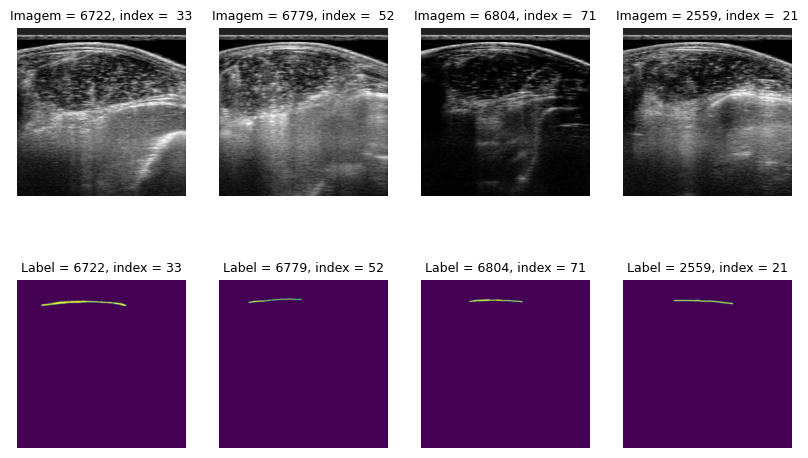

In [7]:
# Plot da função
plot_img_mask(x_train, y_train, num_pairs= 4, label= labels_train)

In [8]:
""" Modifica o banco de dados"""
# x_train
# Função para fazer as modificações nas imagens
dict_x_train, x_train_m = modificacoes1(x_train, 
             nomes_train, 
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

dict_x_val, x_val_m = modificacoes1(x_val,
             nomes_val,
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

print(f'Quantidade de chaves em dict_x_train: {len(dict_x_train.keys())}')
print(f'Quantidade de valores em dict_x_train: {len(dict_x_train.values())}')

Quantidade de chaves em dict_x_train: 372
Quantidade de valores em dict_x_train: 372


In [9]:
# Modificando as labels
y_train_m = dict(zip(nomes_train, y_train))
y_val_m = dict(zip(nomes_val, y_val))
print(f'Quantidade de chaves em y_train: {len(y_train_m)}')   
print(f'Quantidade de chaves em y_val: {len(y_val_m)}')

Quantidade de chaves em y_train: 93
Quantidade de chaves em y_val: 26


In [10]:
# # # y_train
## duplica imagens de label se necessario
y_train_m, y_train_nomes = modificacoes2(y_train_m, dict_x_train.keys())
y_val_m, y_val_nomes = modificacoes2(y_val_m, dict_x_val.keys())

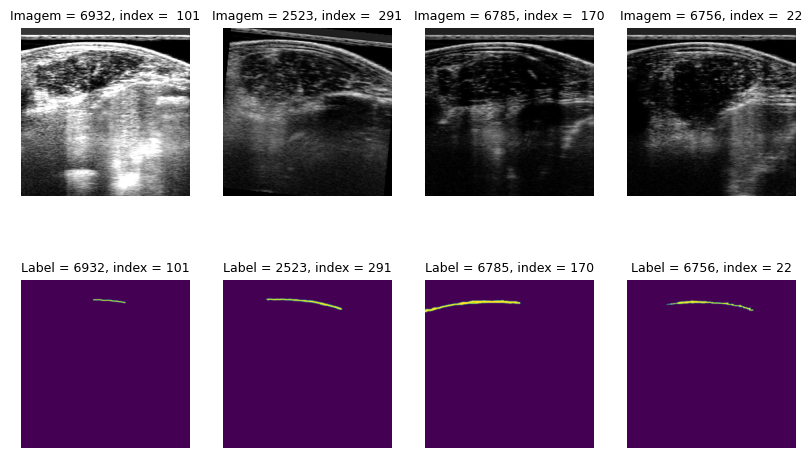

In [11]:
plot_img_mask(x_train_m, y_train_m, num_pairs= 4, label= y_train_nomes)

In [12]:
x_train_m = np.array(x_train_m)
y_train_m = np.array(y_train_m)

x_val_m = np.array(x_val_m)
y_val_m = np.array(y_val_m)

In [13]:
threshold = 0.5
y_train_m = (y_train_m > threshold).astype(np.float32)
y_val_m = (y_val_m > threshold).astype(np.float32)

In [14]:
print(f"Quantidade de imagens em x_train_modificado: {x_train_m.shape}")
print(f"Quantidade de imagens em y_train_modificado: {y_train_m.shape}")

print(f"Quantidade de imagens em x_val_modificado: {x_val_m.shape}")
print(f"Quantidade de imagens em y_val_modificado: {y_val_m.shape}")

Quantidade de imagens em x_train_modificado: (372, 256, 256, 1)
Quantidade de imagens em y_train_modificado: (372, 256, 256, 1)
Quantidade de imagens em x_val_modificado: (104, 256, 256, 1)
Quantidade de imagens em y_val_modificado: (104, 256, 256, 1)


In [28]:
class_train = enc.fit_transform(
    np.array([0 if nome[2:3] == '6' else 1 for nome in y_train_nomes]).reshape(-1, 1)
)
class_val = enc.transform(
    np.array([0 if nome[2:3] == '6' else 1 for nome in y_val_nomes]).reshape(-1, 1)
)
class_test = enc.transform(
    np.array([0 if nome[2:3] == '6' else 1 for nome in nomes_test]).reshape(-1, 1)
)
# class_train.shape → (N, 2)
print(class_test)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


## Dados desbalanceados
- Estou fazendo isso pois na EGL a máscara tem mais pixels pretos do que brancos. 

In [15]:
from sklearn.utils import class_weight

# Vetorize as labels para calcular os class weights
threshold = 0.5
y_train_limiar = (y_train_m > threshold).astype(int)
y_train_flat = y_train_limiar.flatten()
classes = np.unique(y_train_flat)
print("Classes encontradas:", classes)
# Calcule os class weights
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_train_flat)
class_weights_dict = dict(enumerate(class_weights))

w0 = float(class_weights_dict[0])
w1 = float(class_weights_dict[1])

Classes encontradas: [0 1]


In [33]:
import json

with open("class_weights_egl_v3.json", "w") as f:
    json.dump(class_weights_dict, f, indent=2)

## Salvando x_teste para testes futuros

In [16]:
# Pasta base de saída
out_base = "banco2/TreinoGeral/EGL/validacaoGeralUnetFuzzy"
out_x = os.path.join(out_base, "x_test")
out_y = os.path.join(out_base, "y_test")
os.makedirs(out_x, exist_ok=True)
os.makedirs(out_y, exist_ok=True)

def to_uint8(img):
    """Converte imagem para uint8 [0,255], tratando float/bool e canal único."""
    arr = np.squeeze(img)  # remove canal extra (H,W,1) -> (H,W)
    if arr.dtype == np.bool_:
        arr = arr.astype(np.uint8) * 255
    elif np.issubdtype(arr.dtype, np.floating):
        # Se estiver normalizada em [0,1], escala para [0,255]
        arr = np.clip(arr, 0, 1)
        arr = (arr * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)
    return arr

for i in range(len(x_test)):
    nome_base = nomes_test[i] if "nomes_test" in globals() and i < len(nomes_test) else f"img_{i:04d}"
    nome_base = os.path.splitext(os.path.basename(str(nome_base)))[0]

    img_x = to_uint8(x_test[i])
    img_y = to_uint8(y_test[i])

    cv2.imwrite(os.path.join(out_x, f"{nome_base}.jpg"), img_x)
    cv2.imwrite(os.path.join(out_y, f"{nome_base}.jpg"), img_y)

print(f"Salvo em: {os.path.abspath(out_base)}")
print(f"Total de pares salvos: {len(x_test)}")

Salvo em: /home/victors/Documents/Codigos_Mestrado/banco2/TreinoGeral/EGL/validacaoGeralUnetFuzzy
Total de pares salvos: 15


## Métricas & Funções

In [29]:
# Definindo uma função de perda baseada nos class weights
def weighted_binary_crossentropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    # Binary crossentropy padrão
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    # Aplica os pesos às classes
    weights = y_true * w1 + (1.0 - y_true)*w0

    return tf.reduce_mean(bce * weights)

In [30]:
# Converting the arrays into tf.data batches (mais leve e eficiente)
import gc
AUTOTUNE = tf.data.AUTOTUNE

# Se ainda der OOM, o 1o ajuste e reduzir batch_size
batch_size = 1

In [31]:
""" setting DICE coefficient to evaluate the model """
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten per-sample to compute Dice over all pixels
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)
    dice_coeff = (2.0 * intersection + smooth) / (union + smooth)
    return dice_coeff

In [20]:
""" setting DICE loss to train the model"""

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

In [42]:
""" Função: calcular área (predição vs máscara) na dimensão original (403x333) """
def comparar_area_predicao(
    idx,
    model,
    x_imgs,
    y_masks,
    funcao = None,
    nomes_dados = None,
    orig_size=(403, 333),
    threshold=0.5,
    px_per_cm=24.05,
    smooth=1e-6,
    plot=False,
    overlay_alpha=0.35,
    contours=True,
    verbose=True,
 ):
    orig_h, orig_w = orig_size  # (H, W)
    cm_per_px = 1.0 / px_per_cm 
    # Pega amostra
    if len(x_imgs)> 1:
        x = x_imgs[0][idx]
        x_class = x_imgs[1][idx]
        y_true = y_masks[idx]
        # Predição (probabilidade)
        x_in = tf.expand_dims(x, axis=0)
        x_class_in = tf.expand_dims(x_class, axis=0)
        y_pred = model.predict((x_in, x_class_in), verbose=0)
        y_pred = np.squeeze(y_pred)

        if x_class[0] == 0:
            x_class_str = 'Nelore'
        elif x_class[1] == 0:
            x_class_str = 'Caracu'
    else:
        x = x_imgs[idx]
        y_true = y_masks[idx]
        # Predição (probabilidade)
        x_in = tf.expand_dims(x, axis=0)
        y_pred = model.predict(x_in, verbose=0)
        y_pred = np.squeeze(y_pred)
    # Binariza
    y_pred_bin = (y_pred >= threshold).astype(np.uint8)
    y_true = np.squeeze(y_true)
    # Se a máscara veio como 0..255, normaliza implicitamente via threshold
    y_true_bin = (y_true >= threshold).astype(np.uint8)
    # Garante 2D
    if y_pred_bin.ndim == 3:
        y_pred_bin = np.squeeze(y_pred_bin)
    if y_true_bin.ndim == 3:
        y_true_bin = np.squeeze(y_true_bin)
    # Resize para dimensão original (OpenCV usa (W,H))
    pred_orig = cv2.resize(y_pred_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    true_orig = cv2.resize(y_true_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    # Áreas (px²) e (cm²)
    
    # Diametro vertical (de cima para baixo) na dimensão original
    def _diametro_vertical(mask: np.ndarray) -> int:
        max_len = 0
        # best_col = -1
        # best_row_start = -1

        rows, cols = mask.shape

        for col in range(cols):
            current_len = 0
            row_start = -1
            for row in range(rows):
                if mask[row, col] == 1:
                    if current_len == 0:
                        row_start = row
                    current_len += 1

                    if current_len > max_len:
                        max_len = current_len
                        # best_col = col
                        # best_row_start = row_start
                else:
                    current_len = 0
        return max_len

    def _media_vertical(mask: np.ndarray) -> float:
        lengths = []
        rows, cols = mask.shape

        for col in range(cols):
            current_len = 0
            for row in range(rows):
                if mask[row, col] == 1:
                    current_len += 1
                else:
                    if current_len > 0:
                        lengths.append(current_len)
                    current_len = 0
            if current_len > 0:
                lengths.append(current_len)

        return np.mean(lengths) if lengths else 0.0
    
    def _diametro_horizontal(mask: np.ndarray) -> int:
        rows, cols = mask.shape
        max_len = 0
        best_col_start = cols
        best_col_end = 0

        for row in range(rows):
            col_start = cols
            col_end   = 0
            for col in range(cols):
                if mask[row, col] == 1:
                    if col_start == cols:
                        col_start = col

                    if col > col_end:
                        col_end = col

                else:
                    if col_start <= best_col_start:
                        best_col_start = col_start
                    if col_end > best_col_end:
                        best_col_end = col_end
        max_len = best_col_end - best_col_start + 1
        w_dt = int(2*max_len/3)
        cont = 0
        height = 0
        for row in range(rows):
            if mask[row, best_col_start+w_dt] == 1:
                cont += 1
            else:
                if cont > height:
                    height = cont
                cont = 0
        

        
        return height
    
    funcao = funcao.lower().split()
    funcao = funcao[0] if len(funcao) > 0 else None
    
    if funcao == 'm':
        diam_pred_px = _media_vertical(pred_orig)
        diam_true_px = _media_vertical(true_orig)
    elif funcao == 'h':
        diam_pred_px = _diametro_horizontal(pred_orig)
        diam_true_px = _diametro_horizontal(true_orig)
    else:
        diam_pred_px = _diametro_vertical(pred_orig)
        diam_true_px = _diametro_vertical(true_orig)


    
    diam_pred_cm = diam_pred_px * cm_per_px
    diam_true_cm = diam_true_px * cm_per_px
    diam_diff_px = np.abs(diam_pred_px - diam_true_px)
    diam_diff_cm = np.abs(diam_diff_px * cm_per_px)
    # Métricas na dimensão original
    intersection = int((pred_orig & true_orig).sum())
    union = int((pred_orig | true_orig).sum())
    iou = (intersection + smooth) / (union + smooth)



    

    result = {
        'idx': idx,
        'orig_size': (orig_h, orig_w),
        'threshold': float(threshold),
        'px_per_cm': float(px_per_cm),
        'diam_pred_px': int(diam_pred_px),
        'diam_true_px': int(diam_true_px),
        'diam_pred_cm': float(diam_pred_cm),
        'diam_true_cm': float(diam_true_cm),
        'diam_diff_px': int(diam_diff_px),
        'diam_diff_cm': float(diam_diff_cm),
        'iou_orig': float(iou),
    }
    if verbose:
        print(
            f"diam_true={diam_true_cm:.3f} cm | diam_pred={diam_pred_cm:.3f} cm | "
            f"diam_diff={diam_diff_cm:+.3f} cm | "
            f"classe={x_class_str}"
        )
    if plot:
        img = np.squeeze(x)
        # Mostra na dimensão do modelo (p/ referência) e overlays na dimensão original
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        if nomes_dados is not None and len(nomes_dados) > idx:
            plt.title(f'Imagem (modelo) idx={idx} | {nomes_dados[idx][2:6]}')
        else:
            plt.title(f'Imagem (modelo) idx={idx}')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(true_orig, cmap='gray')
        plt.title(f'Máscara verdadeira (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(pred_orig, cmap='gray')
        plt.title(f'Máscara predita (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.show()
        # Overlay (opcional)
        plt.figure(figsize=(7, 7))
        plt.imshow(cv2.resize(img, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR), cmap='gray') # Plano de fundo
        plt.imshow(true_orig, cmap='Reds', alpha=overlay_alpha, vmin=0, vmax=1)
        plt.imshow(pred_orig, cmap='Blues', alpha=overlay_alpha, vmin=0, vmax=1)
        if contours:
            try:
                plt.contour(true_orig, levels=[0.5], colors='red', linewidths=1)
                plt.contour(pred_orig, levels=[0.5], colors='deepskyblue', linewidths=1)
            except Exception:
                pass
        plt.title(f'Overlay (orig) idx={idx} | true=vermelho | pred=azul')
        plt.axis('off')
        plt.show()
    return result

## Modelo

In [32]:
shuffle_buffer = min(256, len(x_train_m))

# Evita float64 acidental em RAM
x_train_m = x_train_m.astype(np.float32, copy=False)
y_train_m = y_train_m.astype(np.float32, copy=False)
x_val_m = x_val_m.astype(np.float32, copy=False)
y_val_m = y_val_m.astype(np.float32, copy=False)
x_val = x_val.astype(np.float32, copy=False)
y_val = y_val.astype(np.float32, copy=False)

# train_data = tf.data.Dataset.from_tensor_slices((x_train_m, y_train_m))
# train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
# train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

# val_data = tf.data.Dataset.from_tensor_slices((x_val_m, y_val_m))
# val_data = val_data.batch(batch_size).prefetch(AUTOTUNE)

# test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
# test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)

"""Para Unet com classificação"""
train_data = tf.data.Dataset.from_tensor_slices(((x_train_m, class_train), y_train_m))
train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices(((x_val_m, class_val), y_val_m))
val_data = val_data.batch(batch_size).prefetch(AUTOTUNE)

# test_data = tf.data.Dataset.from_tensor_slices(((x_test, class_test), y_test))
# test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)

In [23]:
# Libera copias grandes da CPU RAM
del x_train, y_train, x_test, y_test, labels_train
del nomes_train, nomes_test, y_train_nomes, y_val_nomes
del dict_x_train, dict_x_val, x_train_m, y_train_m, x_val_m, y_val_m
gc.collect()

16869

In [29]:
""" U-net """
tf.keras.backend.clear_session()
gc.collect()

# Garante que o modelo segue o shape real dos dados
input_shape = tuple(x_val.shape[1:])  # (H, W, C)

with strategy.scope():
    # Modelo menor para caber na GPU (tente 32; se ainda der OOM, use 16)
    unet = unet(input_shape=input_shape, base_filters=64, max_filters=512, use_class_input=True)
    unet.compile(
        loss='binary_crossentropy',
        optimizer='adam', # Taxa de aprendizado padrão é de 0.001
        metrics=[dice_coefficient],
    )
unet.summary()

Model: "U-Net-Conditioned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ animal_class        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │      2,048 │ animal_class[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                 

 Total params: 27,551,041 (105.10 MB)

 Trainable params: 27,551,041 (105.10 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
""" Unet-Fuzzy com input de classe (multitask) """
input_shape = tuple(x_val.shape[1:])

with strategy.scope():
    unetFuzzy = unet_fuzzy(
        input_shape=(256, 256, 1),
        base_filters=64,
        max_filters=512,
        use_class_input=2,
        use_fuzzy=True,
        num_fuzzy_sets=3,    # Baixo / Médio / Alto
        num_fuzzy_rules=16,  # 16 regras fuzzy no bottleneck
    )
    unetFuzzy.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient],
    )
unetFuzzy.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_23[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_6[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │  2,359,808 │ conv2d_25[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ animal_class        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_7[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │      3,072 │ animal_class[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 16, 16,    │  9,438,208 │ conv2d_27[0][0]   │
│                     │ 1024)             │            │                 

 Total params: 27,628,865 (105.40 MB)

 Trainable params: 27,626,817 (105.39 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [34]:
""" Defining early stopping callback """
early_stopping = EarlyStopping(monitor='val_dice_coefficient', patience=20, restore_best_weights=True, mode='max')

## Treino

In [35]:
unetFuzzy_history = unetFuzzy.fit(
    train_data,
    validation_data=val_data,
    epochs=200,
    callbacks=[early_stopping],
)

# Save the model
unetFuzzy.save('modelos/unet_model_EGL_GeralUnetFuzzy.keras')

Epoch 1/200


I0000 00:00:1774902254.736815   20429 service.cc:153] XLA service 0x7dfacc054dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774902254.736855   20429 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774902254.926230   20429 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774902257.657745   20429 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774902257.855922   20429 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12387__.141


  3/372 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.5689 - dice_coefficient: 0.0047 - loss: 0.6926   

I0000 00:00:1774902315.685807   20429 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


372/372 ━━━━━━━━━━━━━━━━━━━━ 96s 69ms/step - accuracy: 0.9947 - dice_coefficient: 0.0522 - loss: 0.0637 - val_accuracy: 0.9967 - val_dice_coefficient: 0.0151 - val_loss: 0.0254
Epoch 2/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9967 - dice_coefficient: 0.1472 - loss: 0.0114 - val_accuracy: 0.9967 - val_dice_coefficient: 0.0866 - val_loss: 0.0376
Epoch 3/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9967 - dice_coefficient: 0.2077 - loss: 0.0100 - val_accuracy: 0.9968 - val_dice_coefficient: 0.2605 - val_loss: 0.0084
Epoch 4/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9976 - dice_coefficient: 0.3592 - loss: 0.0074 - val_accuracy: 0.9979 - val_dice_coefficient: 0.4433 - val_loss: 0.0080
Epoch 5/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9980 - dice_coefficient: 0.4749 - loss: 0.0062 - val_accuracy: 0.9976 - val_dice_coefficient: 0.3531 - val_loss: 0.0248
Epoch 6/200
372/372 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 

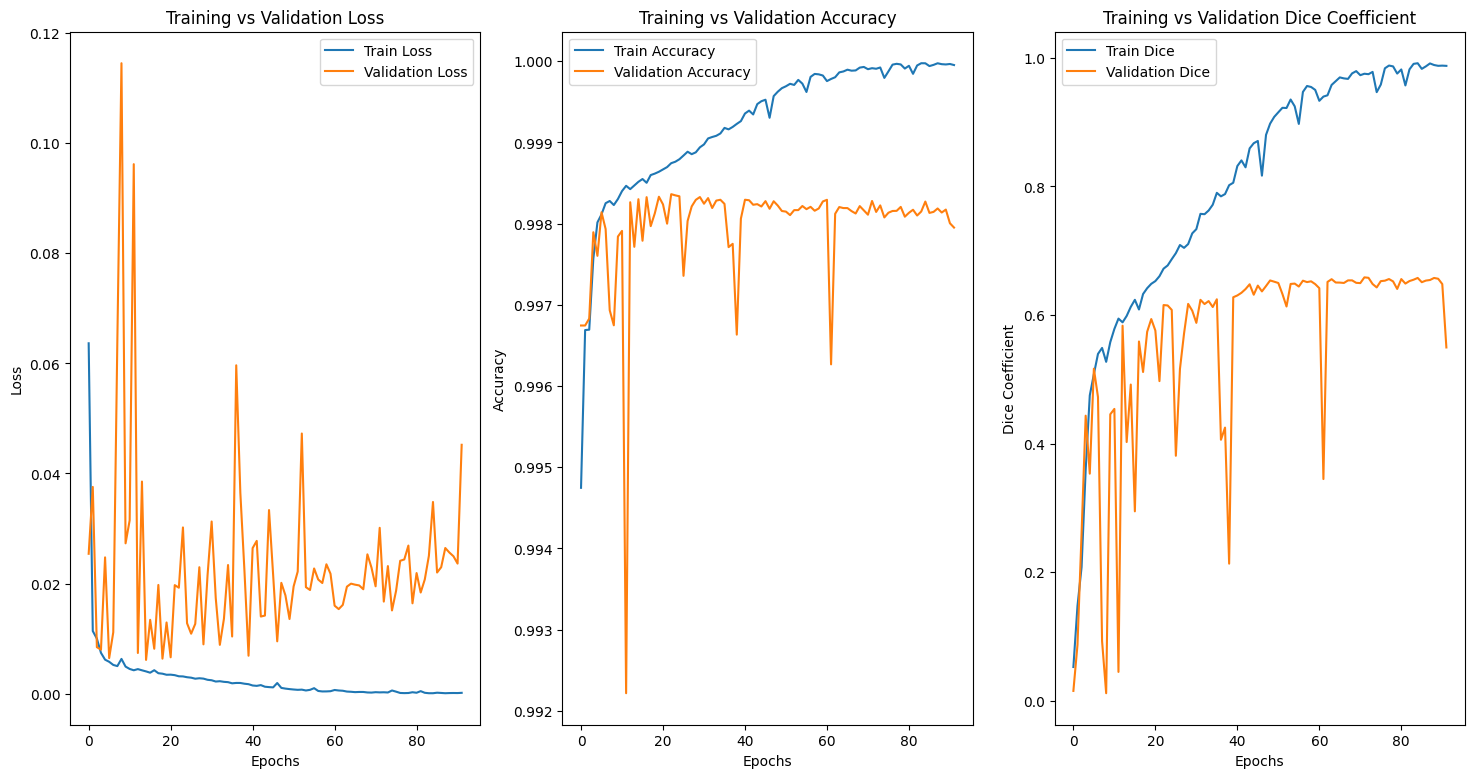

In [36]:
""" plotting the loss and accuracy during training and validation """
plt.figure(figsize=(18, 9))
plt.subplot(1, 3, 1)
plt.plot(unetFuzzy_history.history['loss'])
plt.plot(unetFuzzy_history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.subplot(1, 3, 2)
plt.plot(unetFuzzy_history.history['accuracy'])
plt.plot(unetFuzzy_history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.subplot(1, 3, 3)
plt.plot(unetFuzzy_history.history['dice_coefficient'])
plt.plot(unetFuzzy_history.history['val_dice_coefficient'])
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Training vs Validation Dice Coefficient')
plt.legend(['Train Dice', 'Validation Dice'])

## Apaga alguns dados da memória

In [32]:
del unet_history
del train_data
del unet
gc.collect()

2884

## Carrega Modelo

In [37]:
""" Carregando o modelo salvo """
modelo = keras.models.load_model('modelos//unet_model_EGL_GeralUnetFuzzy.keras', custom_objects={'dice_coefficient': dice_coefficient, 'dice_loss': dice_loss, 'weighted_binary_crossentropy': weighted_binary_crossentropy})

## Testando com outros dados

In [40]:
""" Testando outras imagens """
path_x_new = 'banco2/TreinoGeral/EGL/validacaoGeralV4/x_test/'
path_y_new = 'banco2/TreinoGeral/EGL/validacaoGeralV4/y_test/'

x_new, nomes_x_new = banco(path_x_new, resolution=(256,256), grayscale= True, nomes= True)
y_new, nomes_y_new = banco(path_y_new, resolution=(256,256), grayscale= True, nomes= True)

dict_x_new, x_new_mod = modificacoes1(x_new,
             nomes_x_new,
             original = True,
             brilho = 1.7,
             escura= 0.5)

y_new_m, y_new_nomes = modificacoes2(dict(zip(nomes_y_new, y_new)), dict_x_new.keys())


x_new_m = np.array(x_new_mod)
y_new_m = np.array(y_new_m)


# print(f'Novas imagens : {x_new_m.shape}')
# print(f'Novos rótulos : {y_new_m.shape}')
class_test = (
    np.array([[0,1] if nome[2:3] == '6' else [1,0] for nome in y_new_nomes])
)

new_data = tf.data.Dataset.from_tensor_slices(((x_new_m, class_test), y_new_m))
new_data = new_data.batch(batch_size).prefetch(AUTOTUNE)
modelo.evaluate(new_data, verbose= 1)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9886 - dice_coefficient: 0.7619 - loss: 0.0168


[0.016803743317723274, 0.9886491298675537, 0.761934757232666]

diam_true=0.147 cm | diam_pred=0.132 cm | diam_diff=+0.015 cm | classe=Caracu


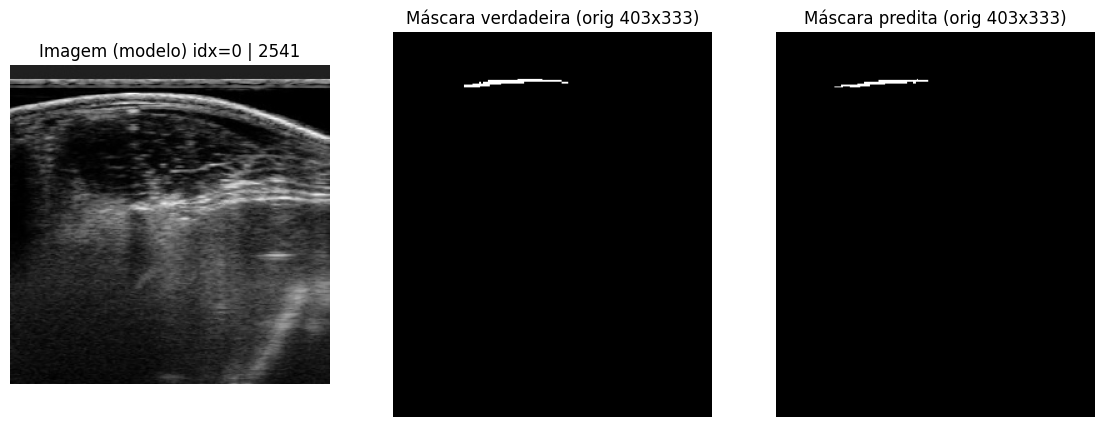

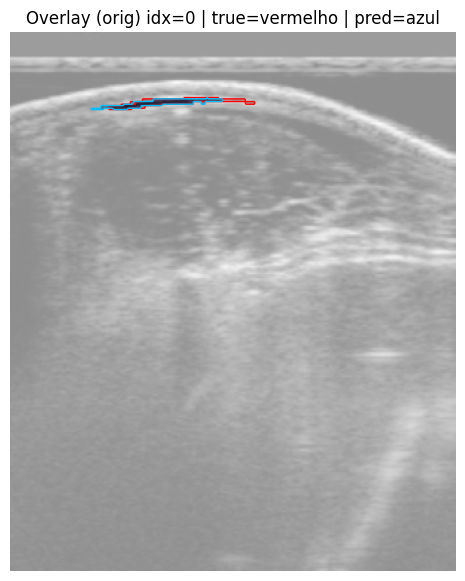

diam_true=0.144 cm | diam_pred=0.134 cm | diam_diff=+0.009 cm | classe=Caracu


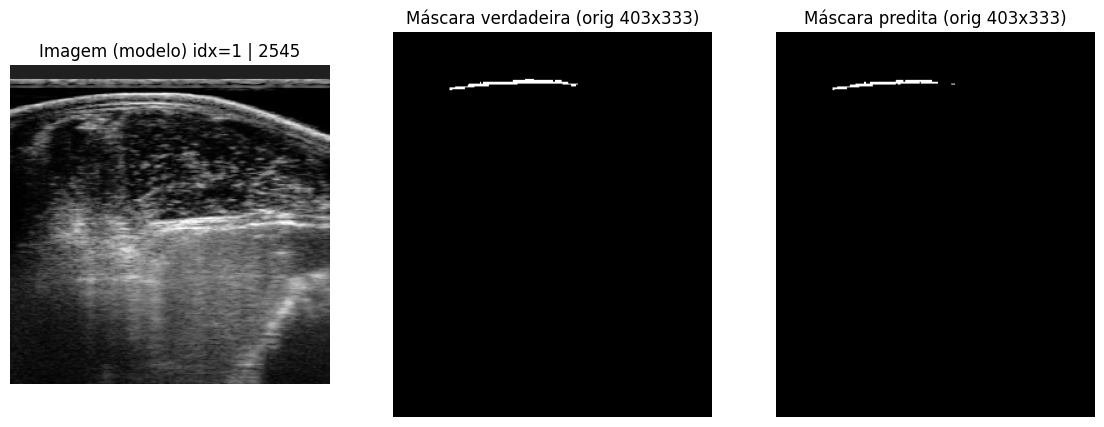

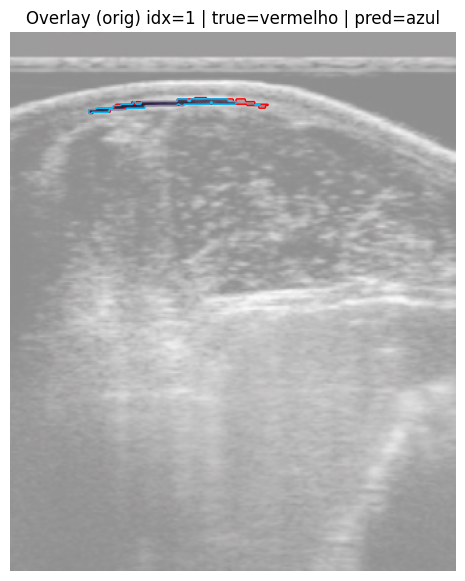

diam_true=0.188 cm | diam_pred=0.169 cm | diam_diff=+0.018 cm | classe=Caracu


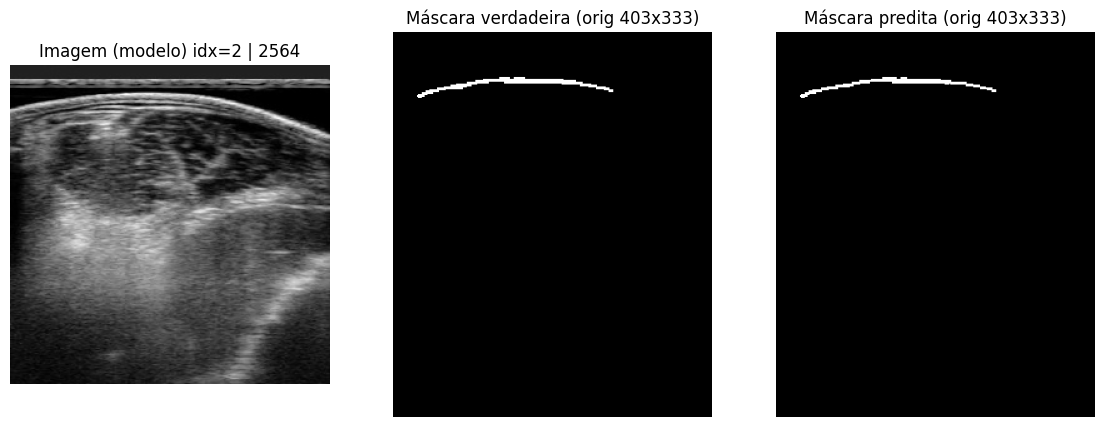

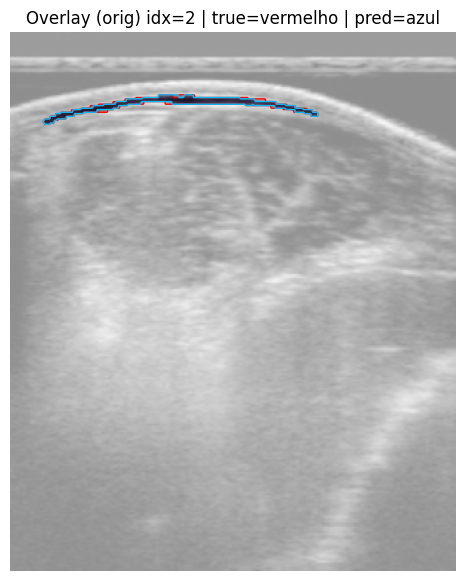

diam_true=0.141 cm | diam_pred=0.140 cm | diam_diff=+0.001 cm | classe=Caracu


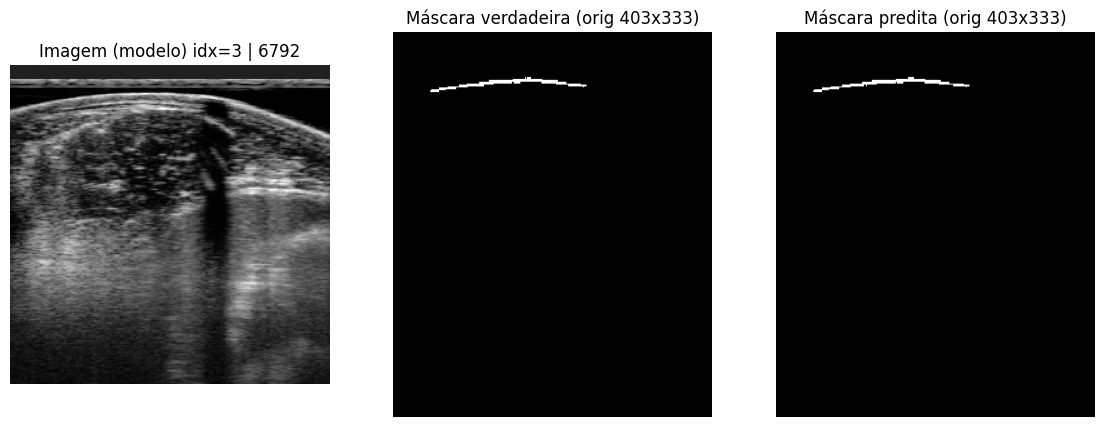

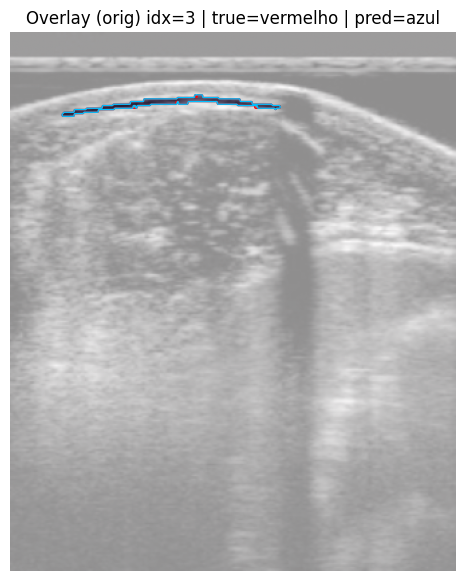

diam_true=0.112 cm | diam_pred=0.137 cm | diam_diff=+0.026 cm | classe=Caracu


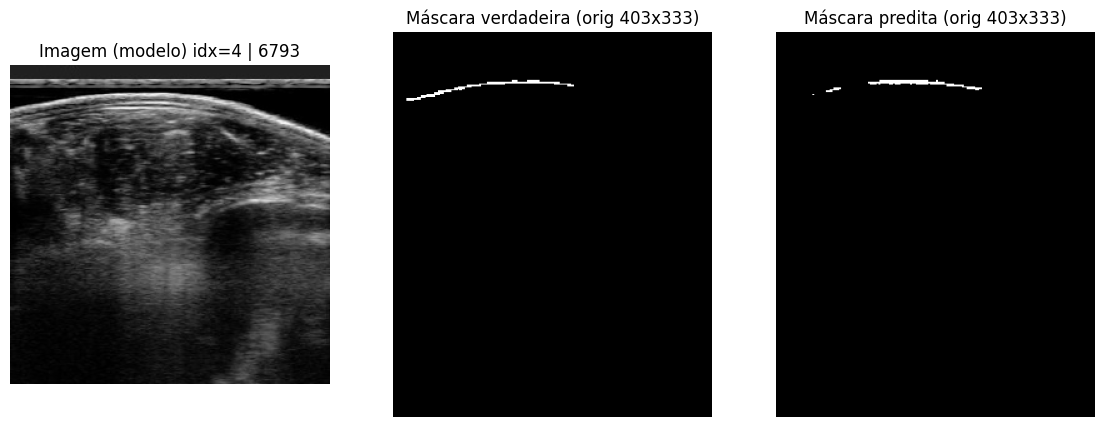

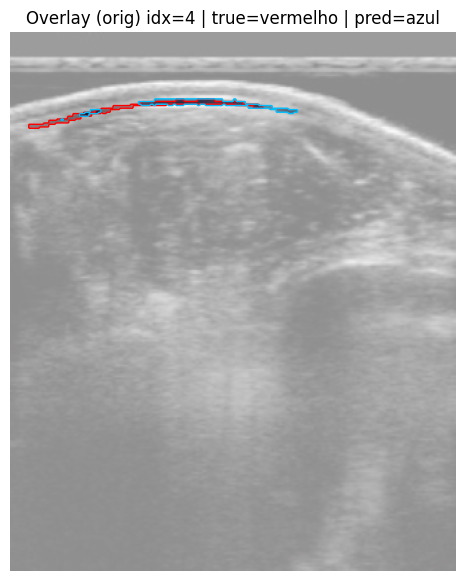

diam_true=0.130 cm | diam_pred=0.130 cm | diam_diff=+0.000 cm | classe=Caracu


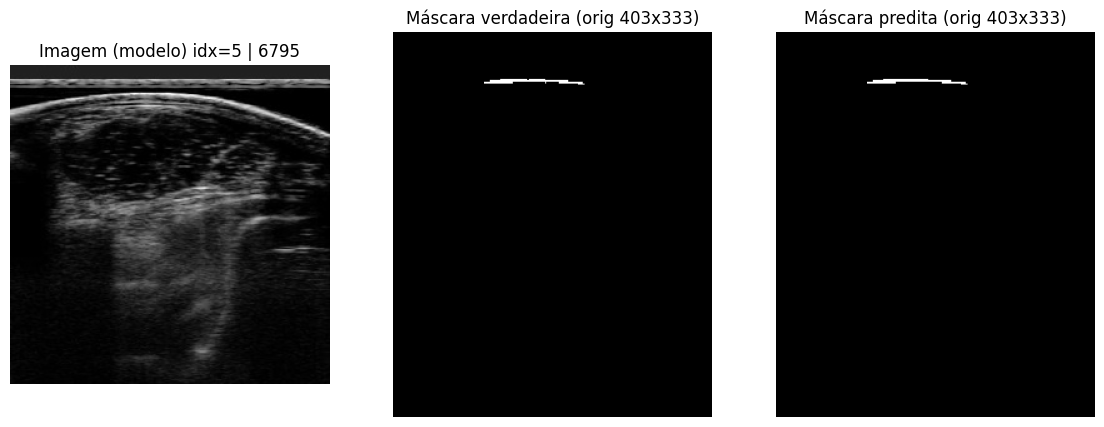

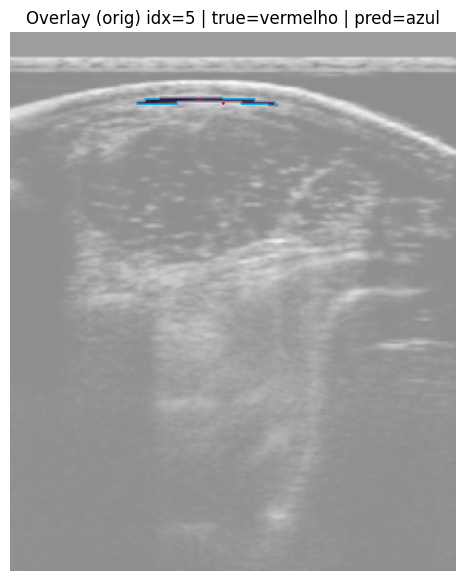

diam_true=0.086 cm | diam_pred=0.084 cm | diam_diff=+0.002 cm | classe=Caracu


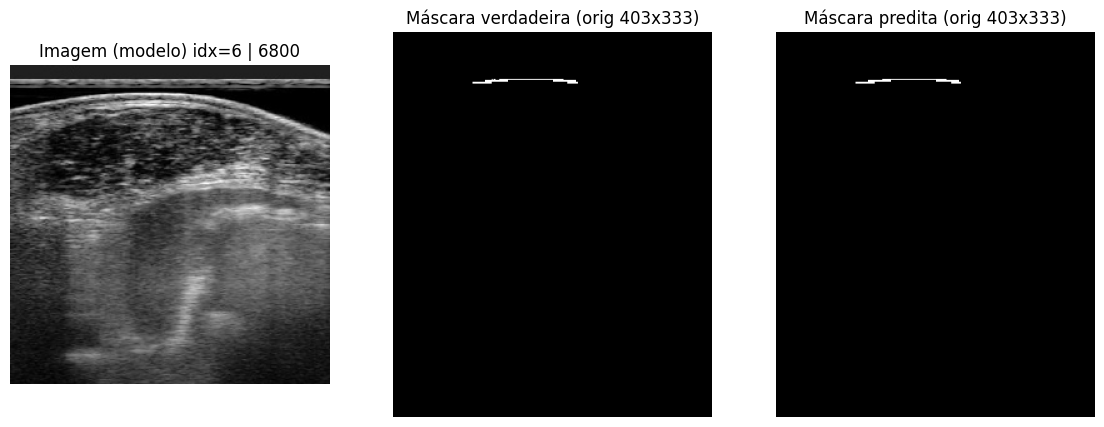

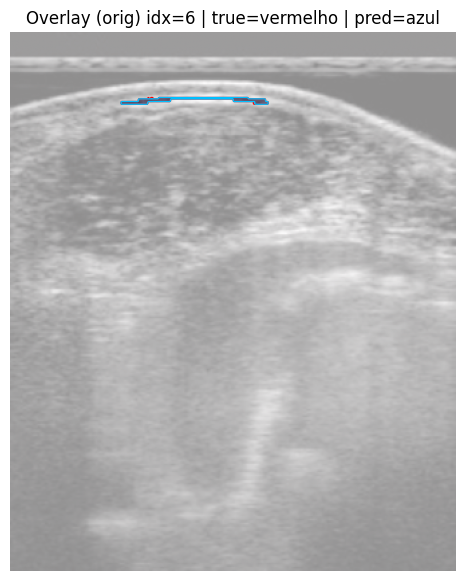

diam_true=0.121 cm | diam_pred=0.122 cm | diam_diff=+0.001 cm | classe=Caracu


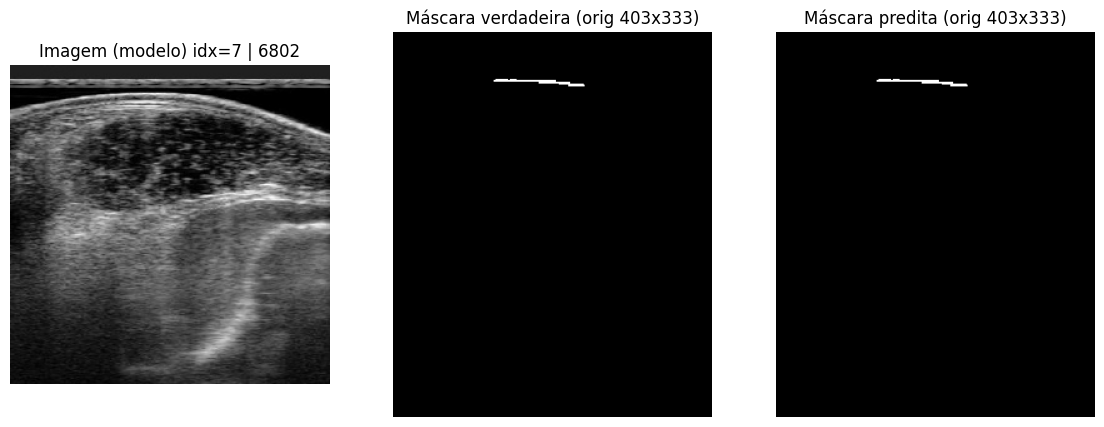

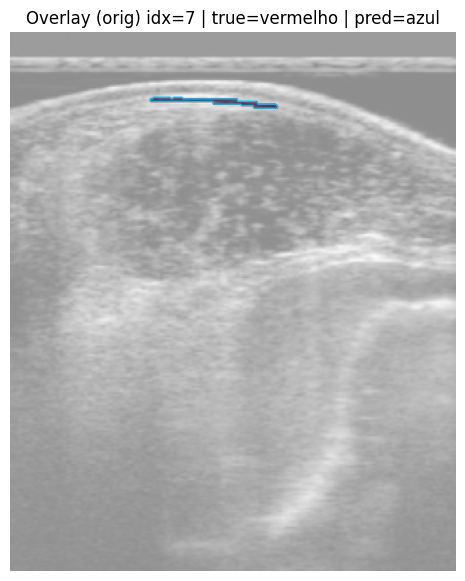

diam_true=0.113 cm | diam_pred=0.116 cm | diam_diff=+0.003 cm | classe=Caracu


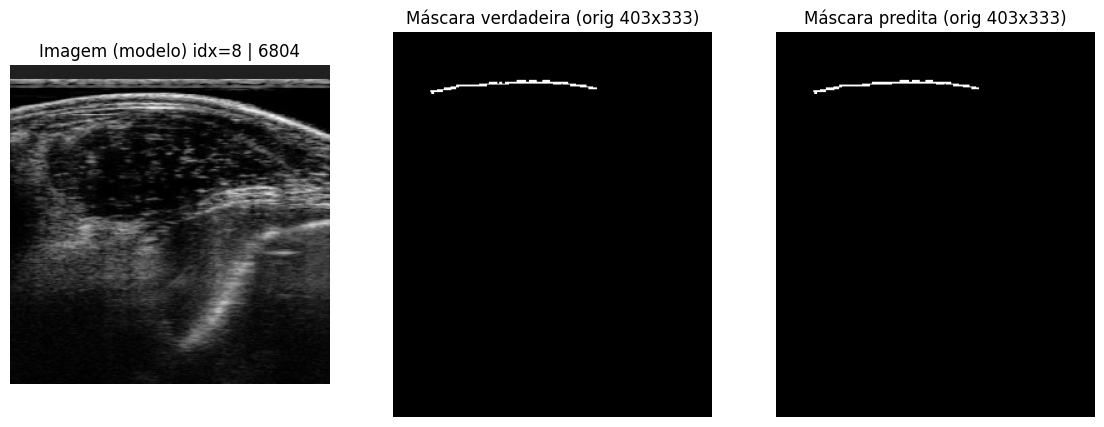

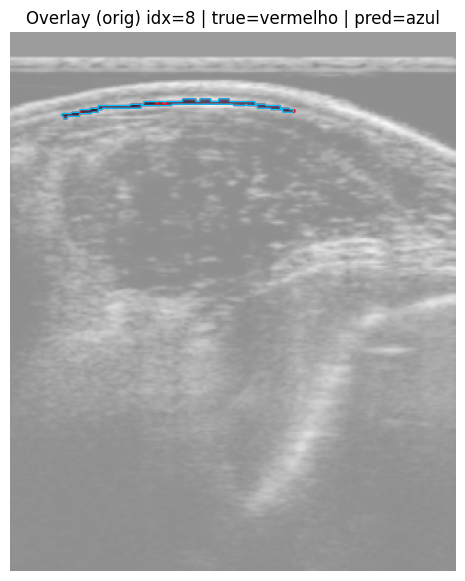

diam_true=0.098 cm | diam_pred=0.106 cm | diam_diff=+0.008 cm | classe=Nelore


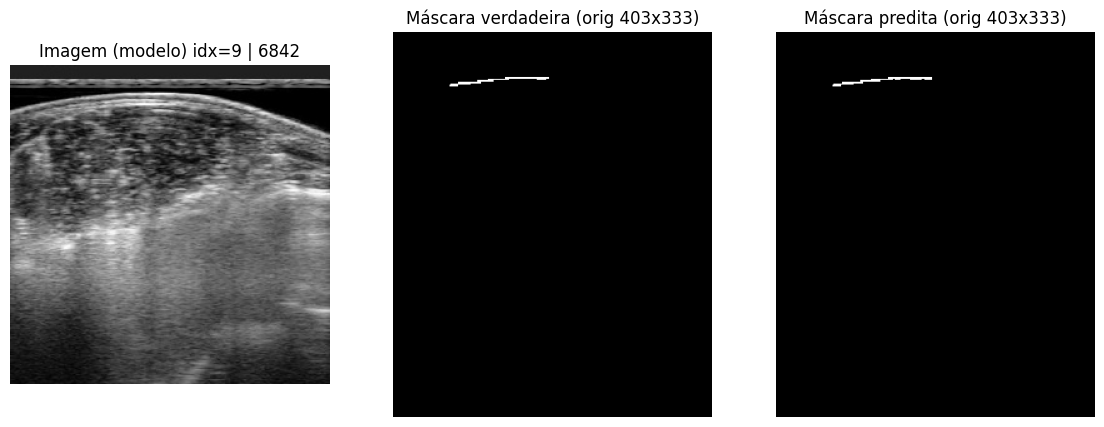

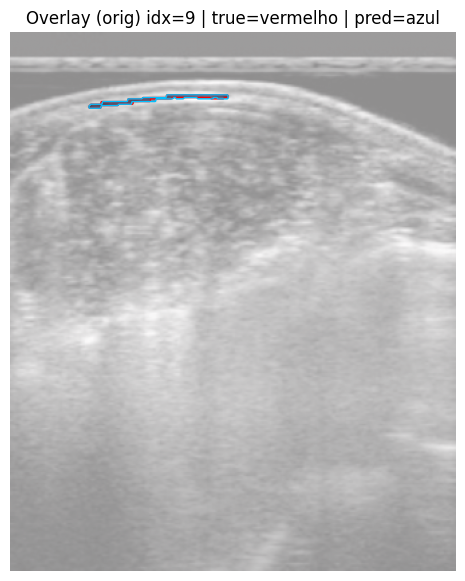

diam_true=0.128 cm | diam_pred=0.117 cm | diam_diff=+0.011 cm | classe=Nelore


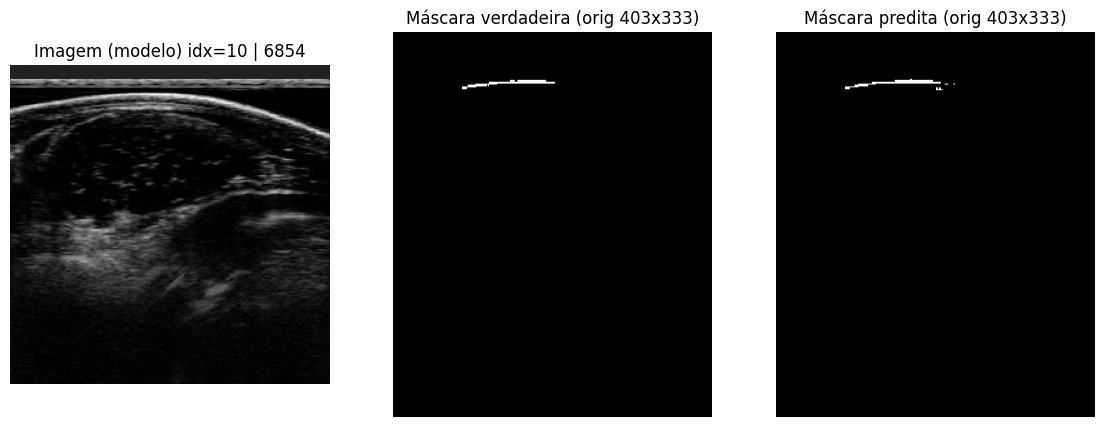

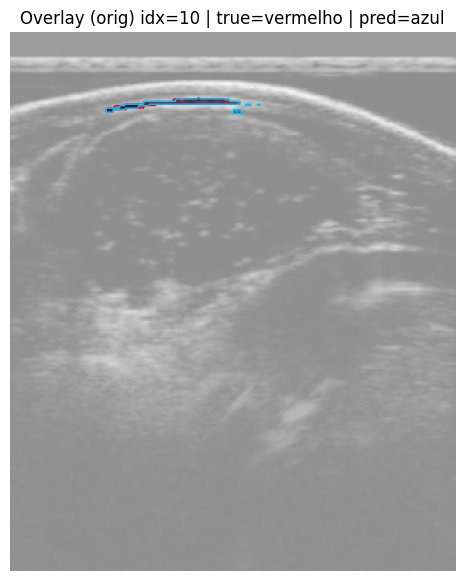

diam_true=0.163 cm | diam_pred=0.165 cm | diam_diff=+0.002 cm | classe=Nelore


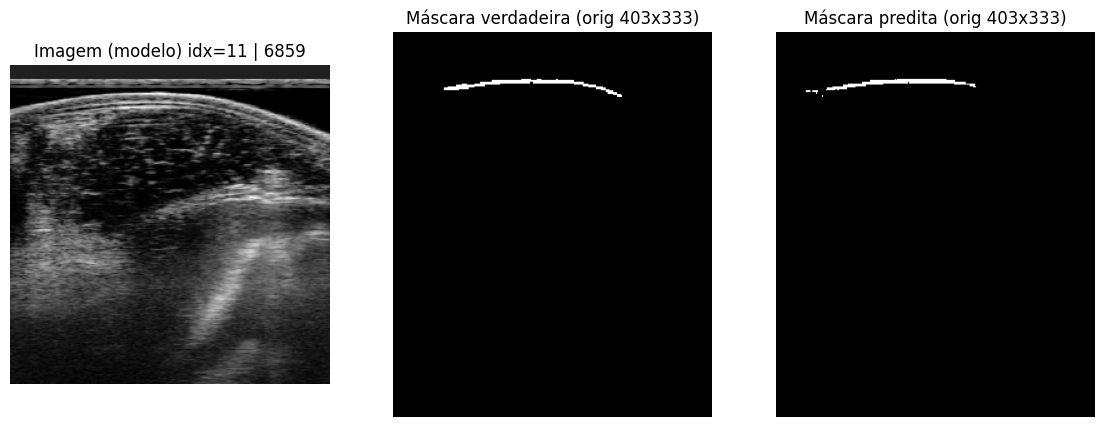

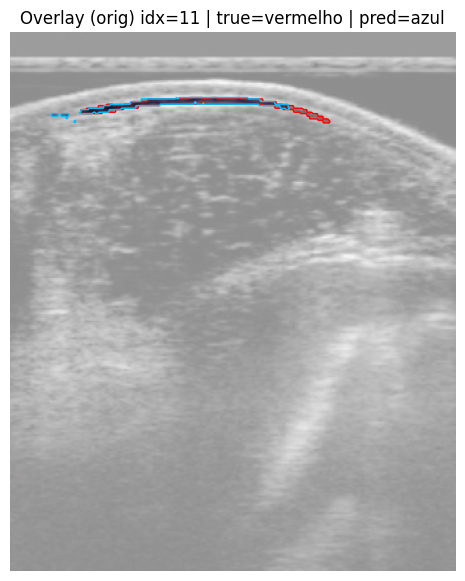

diam_true=0.124 cm | diam_pred=0.130 cm | diam_diff=+0.006 cm | classe=Nelore


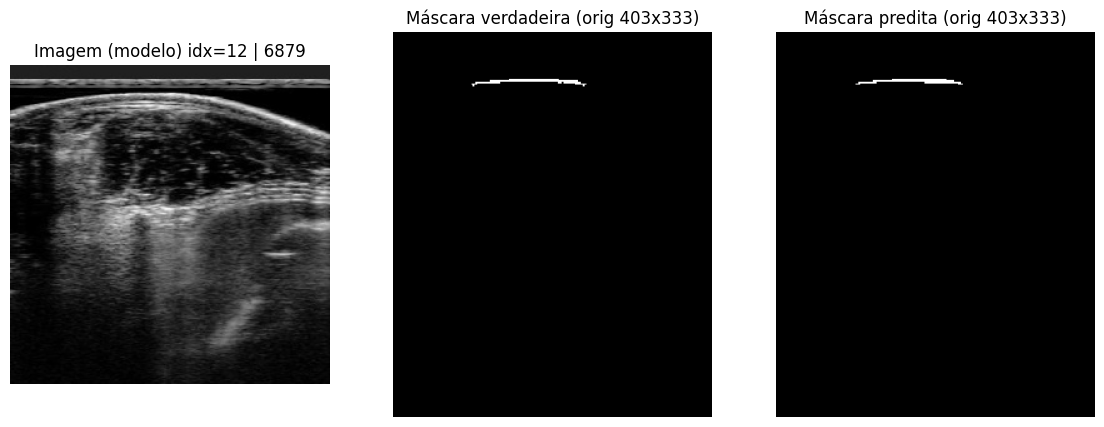

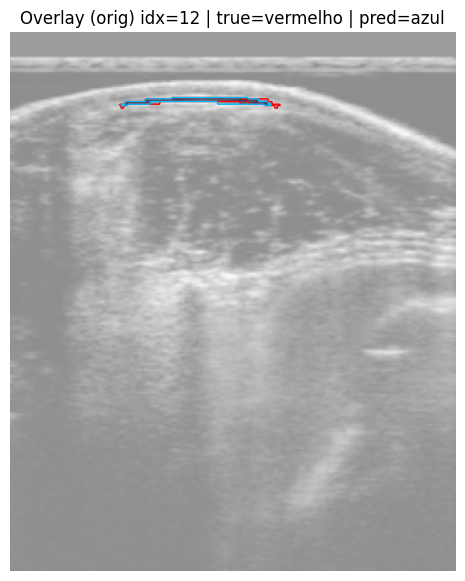

diam_true=0.113 cm | diam_pred=0.140 cm | diam_diff=+0.027 cm | classe=Nelore


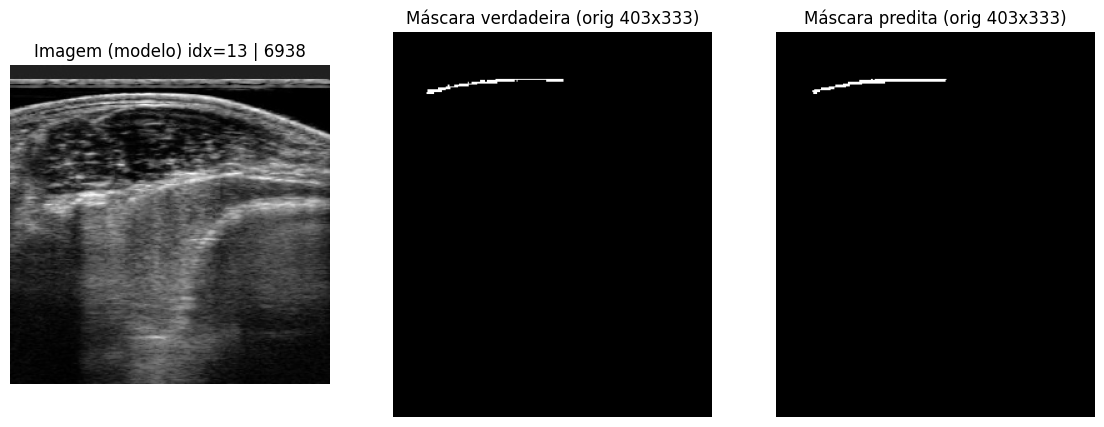

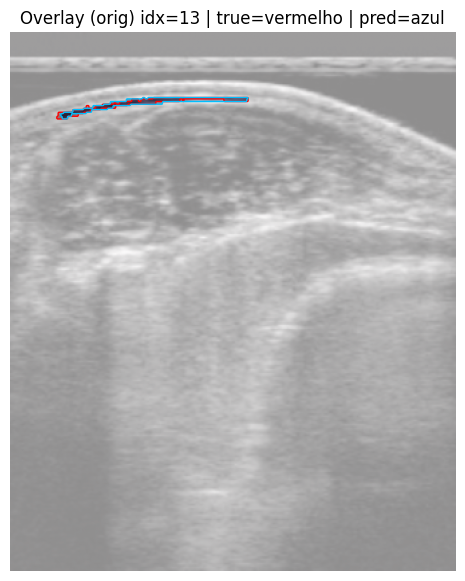

diam_true=0.143 cm | diam_pred=0.154 cm | diam_diff=+0.011 cm | classe=Nelore


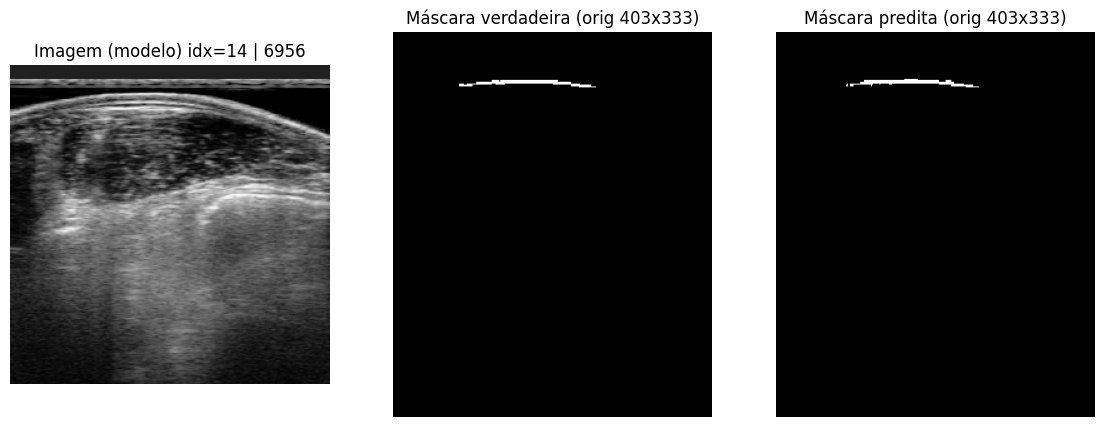

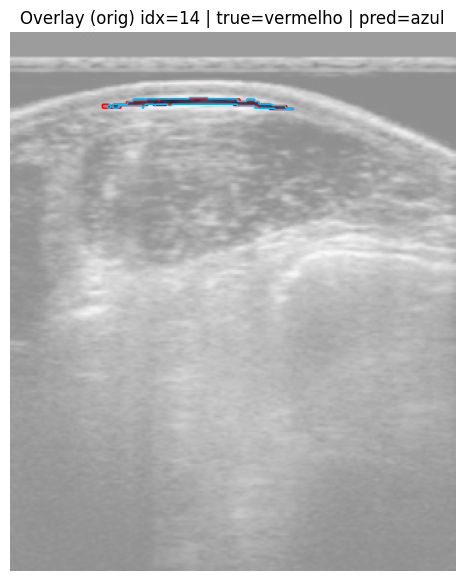

In [44]:
# Print função
for idx in range(len(x_new)):
    comparar_area_predicao(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        funcao='m',
        nomes_dados= nomes_y_new,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=True,
        overlay_alpha=0.35,
        contours=True,
        verbose=True,
    )

In [45]:
# Print função
for idx in range(len(x_new)):
    comparar_area_predicao(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        funcao='h',
        nomes_dados= nomes_y_new,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=False,
        overlay_alpha=0.35,
        contours=True,
        verbose=True,
    )

diam_true=0.125 cm | diam_pred=0.166 cm | diam_diff=+0.042 cm | classe=Caracu
diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.125 cm | diam_pred=0.125 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.083 cm | diam_pred=0.208 cm | diam_diff=+0.125 cm | classe=Caracu
diam_true=0.083 cm | diam_pred=0.083 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.042 cm | diam_pred=0.042 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.083 cm | diam_pred=0.083 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.083 cm | diam_pred=0.125 cm | diam_diff=+0.042 cm | classe=Nelore
diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Nelore
diam_true=0.166 cm | diam_pred=0.208 cm | diam_diff=+0.042 cm | classe=Nelore
diam_true=0.125 cm | diam_pred=0.208 cm | diam_diff=+0.083 cm | 

In [46]:
# Print função
for idx in range(len(x_new)):
    comparar_area_predicao(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        funcao='v',
        nomes_dados= nomes_y_new,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=False,
        overlay_alpha=0.35,
        contours=True,
        verbose=True,
    )

diam_true=0.291 cm | diam_pred=0.208 cm | diam_diff=+0.083 cm | classe=Caracu
diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.291 cm | diam_pred=0.291 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.166 cm | diam_pred=0.166 cm | diam_diff=+0.000 cm | classe=Nelore
diam_true=0.166 cm | diam_pred=0.208 cm | diam_diff=+0.042 cm | classe=Nelore
diam_true=0.249 cm | diam_pred=0.208 cm | diam_diff=+0.042 cm | classe=Nelore
diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 

In [47]:
# Print função
for idx in range(len(x_new)):
    comparar_area_predicao(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        funcao='m',
        nomes_dados= nomes_y_new,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=False,
        overlay_alpha=0.35,
        contours=True,
        verbose=True,
    )

diam_true=0.147 cm | diam_pred=0.132 cm | diam_diff=+0.015 cm | classe=Caracu
diam_true=0.144 cm | diam_pred=0.134 cm | diam_diff=+0.009 cm | classe=Caracu
diam_true=0.188 cm | diam_pred=0.169 cm | diam_diff=+0.018 cm | classe=Caracu
diam_true=0.141 cm | diam_pred=0.140 cm | diam_diff=+0.001 cm | classe=Caracu
diam_true=0.112 cm | diam_pred=0.137 cm | diam_diff=+0.026 cm | classe=Caracu
diam_true=0.130 cm | diam_pred=0.130 cm | diam_diff=+0.000 cm | classe=Caracu
diam_true=0.086 cm | diam_pred=0.084 cm | diam_diff=+0.002 cm | classe=Caracu
diam_true=0.121 cm | diam_pred=0.122 cm | diam_diff=+0.001 cm | classe=Caracu
diam_true=0.113 cm | diam_pred=0.116 cm | diam_diff=+0.003 cm | classe=Caracu
diam_true=0.098 cm | diam_pred=0.106 cm | diam_diff=+0.008 cm | classe=Nelore
diam_true=0.128 cm | diam_pred=0.117 cm | diam_diff=+0.011 cm | classe=Nelore
diam_true=0.163 cm | diam_pred=0.165 cm | diam_diff=+0.002 cm | classe=Nelore
diam_true=0.124 cm | diam_pred=0.130 cm | diam_diff=+0.006 cm | 

In [49]:
""" Calculando a média dos erros"""
erros = []
area_real: list[float] = [] 
area_predita: list[float] = []
for idx in range(len(x_new)):
    resultado = comparar_area_predicao(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        funcao='m',
        nomes_dados= None,
        orig_size=(105, 213),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=False,
        overlay_alpha=0.35,
        contours=True,
        verbose=False,
    )
    erros.append(resultado['diam_diff_cm'])
    area_real.append(resultado['diam_true_cm'])
    area_predita.append(resultado['diam_pred_cm'])

In [50]:
# Print dos erros
print(f'Erro médio na teste: {np.mean(np.abs(erros)):.3f} cm')
print(f'Erro Máximo na teste: {np.max(np.abs(erros)):.3f} cm')
print(f'Erro mínimo na teste: {np.min(np.abs(erros)):.3f} cm')

Erro médio na teste: 0.001 cm
Erro Máximo na teste: 0.002 cm
Erro mínimo na teste: 0.000 cm
